# Minimos Cuadrados

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

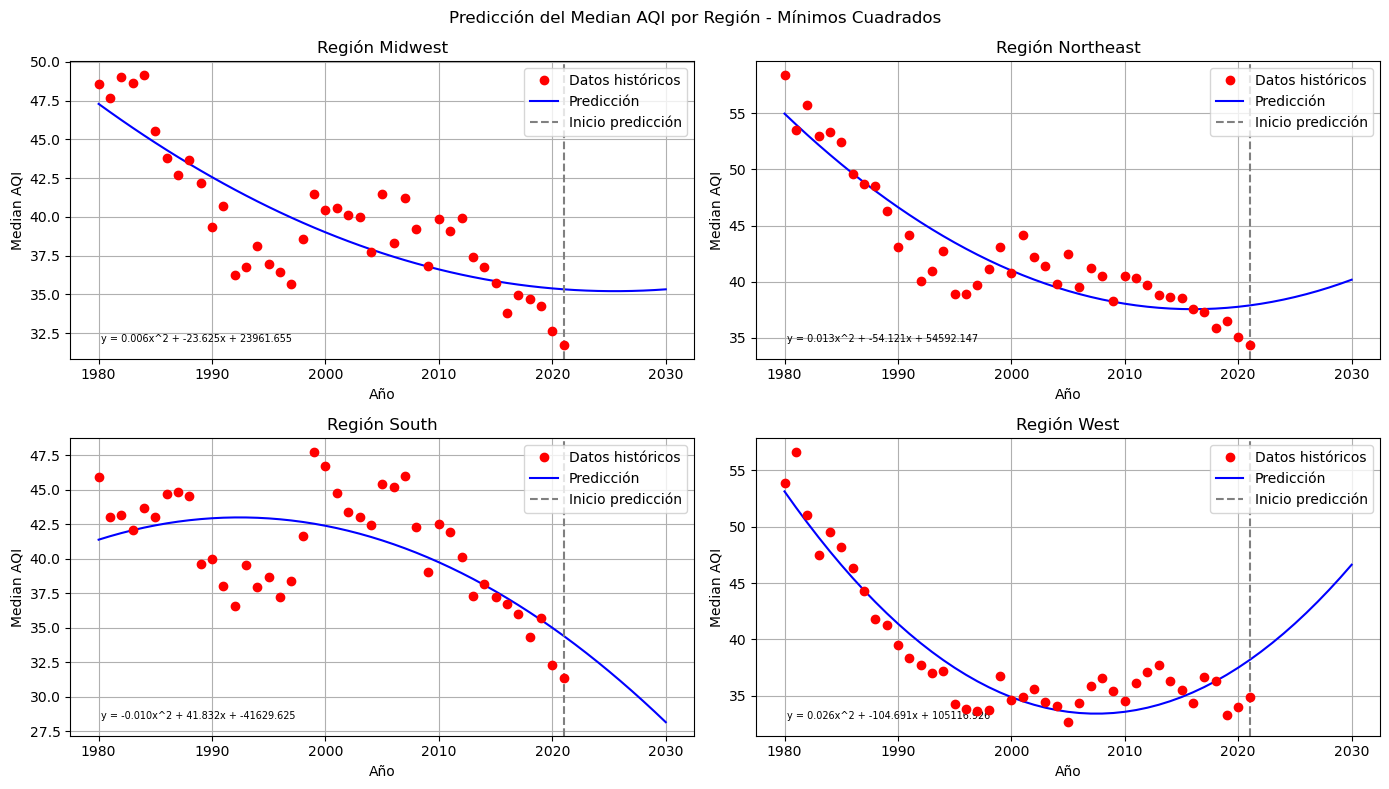

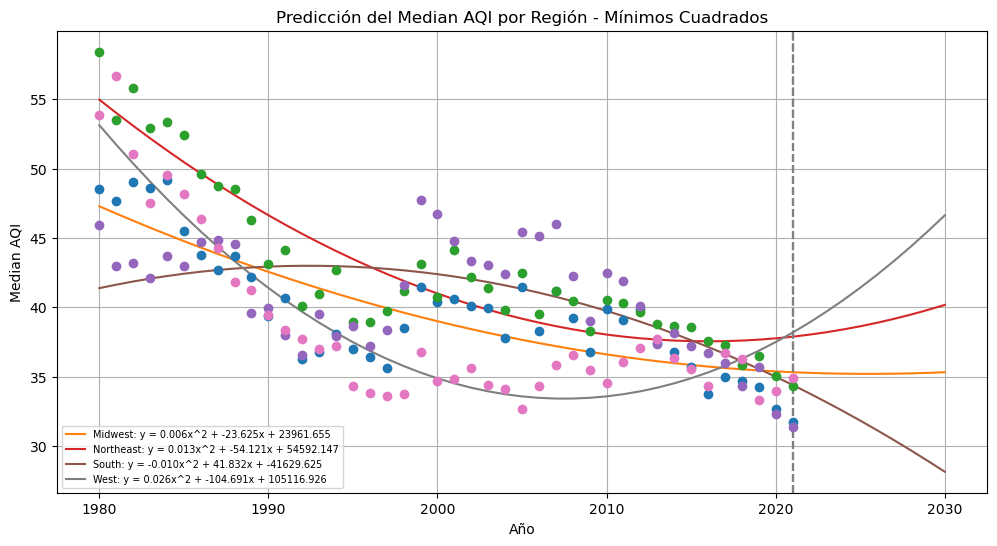

In [8]:
df = pd.read_csv("../dataset/dataset_limpio.csv")

def minimos_cuadrados(x, y, grado):
    """
    Ajusta un polinomio de grado especificado mediante el método de mínimos cuadrados
    y devuelve los coeficientes y la ecuación ajustada.

    Args:
        x (list[float]): Años históricos.
        y (list[float]): Valores históricos del Median AQI.
        grado (int): Grado del polinomio a ajustar.

    Returns:
        tuple: Coeficientes del polinomio y ecuación ajustada en formato string.

    Example:
        >>> coef, ecuacion = minimos_cuadrados(x=[2000,2001,2002], y=[50,48,46], grado=2)
        'y = -0.026x^2 + 0.155x + 1.155'
    """
    x = np.array(x)
    y = np.array(y)
    A = np.vander(x, grado + 1)
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)

    terminos = []

    for i, c in enumerate(coef):
        exp = grado - i
        if exp > 1:
            terminos.append(f"{c:.3f}x^{exp}")
        elif exp == 1:
            terminos.append(f"{c:.3f}x")
        else:
            terminos.append(f"{c:.3f}")
    
    ecuacion = "y = " + " + ".join(terminos)
    return coef, ecuacion


def graficar_prediccion_por_region(df, grado, año_fin):
    """
    Grafica la predicción de mínimos cuadrados de cada región en una subgráfica separada,
    mostrando los datos históricos, la curva ajustada, la predicción y la ecuación.

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.
        grado (int): Grado del polinomio a ajustar.
        año_fin (int): Año hasta el que se quiere predecir.

    Returns:
        None

    Example:
        >>> graficar_prediccion_por_region(df, grado=2, año_fin=2030)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()

    for i, region in enumerate(df['Region'].unique()):
        datos = df[df['Region'] == region].sort_values('Year')
        x = datos['Year'].tolist()
        y = datos['Median AQI'].tolist()

        coef, ecuacion = minimos_cuadrados(x, y, grado)

        años_prediccion = np.arange(x[0], año_fin + 1)
        aqi_predicho = np.polyval(coef, años_prediccion)

        axes[i].plot(x, y, 'o', color='red', zorder=5, label='Datos históricos')
        axes[i].plot(años_prediccion, aqi_predicho, '-', color='blue', label='Predicción')
        axes[i].axvline(x=x[-1], color='gray', linestyle='--', label='Inicio predicción')
        axes[i].set_title(f'Región {region}')
        axes[i].set_xlabel('Año')
        axes[i].set_ylabel('Median AQI')
        axes[i].text(0.05, 0.05, ecuacion, transform=axes[i].transAxes,fontsize=7, verticalalignment='bottom')
        axes[i].legend(loc='upper right')
        axes[i].grid(True)

    plt.suptitle('Predicción del Median AQI por Región - Mínimos Cuadrados')
    plt.tight_layout()
    plt.savefig('../graficas/prediccion_por_region.png')
    plt.show()


def graficar_prediccion_combinado(df, grado, año_fin):
    """
    Grafica la predicción de mínimos cuadrados de todas las regiones en una misma figura.

    Args:
        df (DataFrame): Dataset limpio y agrupado por región y año.
        grado (int): Grado del polinomio a ajustar.
        año_fin (int): Año hasta el que se quiere predecir.

    Returns:
        None

    Example:
        >>> graficar_prediccion_combinado(df, grado=2, año_fin=2030)
    """
    plt.figure(figsize=(12, 6))

    for region in df['Region'].unique():
        datos = df[df['Region'] == region].sort_values('Year')
        x = datos['Year'].tolist()
        y = datos['Median AQI'].tolist()

        coef, ecuacion = minimos_cuadrados(x, y, grado)

        años_prediccion = np.arange(x[0], año_fin + 1)
        aqi_predicho = np.polyval(coef, años_prediccion)

        plt.plot(x, y, 'o', zorder=5)
        plt.plot(años_prediccion, aqi_predicho, '-', label=f'{region}: {ecuacion}')
        plt.axvline(x=x[-1], color='gray', linestyle='--')

    plt.title('Predicción del Median AQI por Región - Mínimos Cuadrados')
    plt.xlabel('Año')
    plt.ylabel('Median AQI')
    plt.legend(fontsize=7)
    plt.grid(True)
    plt.savefig('../graficas/prediccion_combinado.png')
    plt.show()


graficar_prediccion_por_region(df, grado=2, año_fin=2030)
graficar_prediccion_combinado(df, grado=2, año_fin=2030)